In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_pure_noise import LogLike

sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), batched.

    Waveform generation still runs one row at a time inside
    LogLike.log_density_batch (few has no batched API over source
    parameters), but every rfft/inner-product/chi-square step downstream
    of generation is computed once across the whole (B, ndim) batch instead
    of once per row.
    """
    params = np.asarray(params)
    B = params.shape[0]
    logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = (params[:, j] for j in range(7))
    qS_i = np.arccos(cosqS_i)
    theta_batch = np.stack([
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        np.full(B, xI0), np.full(B, dist), qS_i, phiS_i,
        np.full(B, qK), np.full(B, phiK),
        np.full(B, Phi_phi0), np.full(B, Phi_theta0), np.full(B, Phi_r0),
    ], axis=1)
    try:
        return loglike_obj.log_density_batch(theta_batch)
    except Exception:
        return np.full(B, -np.inf)


def prior_transform(u):
    # from stage1_anneal
    # logm1lim = [5.82507, 5.82762]
    # logm2lim = [1.99252, 1.99310]
    # alim = [0.49334, 0.50078]
    # p0lim = [15.70599, 15.75367]
    # e0lim = [0.74388, 0.74418]
    # cosqSlim = [0.79926, 0.86149]    
    # phiSlim = [3.48384, 3.66905]

    logm1lim = [5.82663, 5.82804]
    logm2lim = [1.99282, 1.99316]
    alim =  [0.49785, 0.50193]
    p0lim = [15.69935, 15.72547]
    e0lim = [0.74392, 0.74409]
    cosqSlim = [0.80724, 0.85206]
    phiSlim =  [3.49931, 3.62436]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.82663, 5.82804]
    logm2lim = [1.99282, 1.99316]
    alim =  [0.49785, 0.50193]
    p0lim = [15.69935, 15.72547]
    e0lim = [0.74392, 0.74409]
    cosqSlim = [0.80724, 0.85206]
    phiSlim =  [3.49931, 3.62436]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
#NOTE:corrected
# qS   = 0.5905743164658463
# phiS = 3.580825804842126
# qK   = 0.9327436243181905
# phiK = 3.6550014190179883

In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage3_f_dev/'


In [4]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl', log_density_func=log_density, prior_transform=prior_transform)
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [5]:
sampler.now_covariances

[array([[ 0.00859321,  0.01139728,  0.00908815, -0.00832978, -0.00934995,
         -0.00228508,  0.0055716 ],
        [ 0.01139728,  0.0222092 ,  0.01140084, -0.01017425, -0.0153074 ,
         -0.00845357,  0.01893949],
        [ 0.00908815,  0.01140084,  0.00973511, -0.00890705, -0.00957832,
         -0.00206607,  0.00419633],
        [-0.00832978, -0.01017425, -0.00890705,  0.00819539,  0.00869829,
          0.00160139, -0.00382453],
        [-0.00934995, -0.0153074 , -0.00957832,  0.00869829,  0.01141623,
          0.00436125, -0.01148131],
        [-0.00228508, -0.00845357, -0.00206607,  0.00160139,  0.00436125,
          0.04831411,  0.00462993],
        [ 0.0055716 ,  0.01893949,  0.00419633, -0.00382453, -0.01148131,
          0.00462993,  0.05565484]]),
 array([[ 1.04626449e-02,  3.82538029e-03,  1.08524413e-02,
         -1.28243669e-02, -7.40883024e-03, -4.24145989e-04,
          3.31452014e-03],
        [ 3.82538029e-03,  1.81638685e-02,  2.05255936e-03,
         -2.16308119e

In [6]:
sampler.config

SamplerConfig(seed=953453411, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, save_interval=0, exclude_scale_z=inf, enforce_trail_size=False, use_pool=False, n_pool=10, parallel_eval=True, max_batch_size=None, speculative_n_guess=None, density_selfcheck=False, stop_on_merge=False, merge_type='distance', merge_criterion=None, merge_check_interval=1, sameruler_cloud=1, single_cloud=1, handover_size=0, handover_interleave=2, handover_align_gamma=True, handover_select='top', epoch_evidence=False, coverage_density_gate=False, coverage_force_merge_iter=None, cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [7]:
len(sampler.now_covariances)

9

In [8]:
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

In [ ]:
n_proc = 9  # processes 0..9
maxld_pts = []
for j in range(n_proc):
    nj = sampler.element_num_list[j]
    pt = prior_transform(proc_pt[j][:nj][np.argmax(logden_list[j][:nj])].reshape(1, -1))
    maxld_pts.append(pt)
    print(f"maxld_pt{j+1} =", pt)

maxld_pt1, maxld_pt2, maxld_pt3, maxld_pt4, maxld_pt5, \
maxld_pt6, maxld_pt7, maxld_pt8, maxld_pt9 = maxld_pts

maxld_pt1 = [[ 5.82786211  1.99311317  0.50143058 15.70258108  0.7439405   0.8326975
   3.59057239]]
maxld_pt2 = [[ 5.82769483  1.99283259  0.50114816 15.70277117  0.74406476  0.8496293
   3.61285894]]
maxld_pt3 = [[ 5.82785491  1.99290838  0.50123794 15.70071064  0.74401703  0.84922938
   3.61983526]]
maxld_pt4 = [[ 5.82796139  1.99307933  0.50158277 15.69964985  0.74402242  0.85174155
   3.53534164]]
maxld_pt5 = [[ 5.82746393  1.99312026  0.50180527 15.70926644  0.74397228  0.83224578
   3.54394915]]
maxld_pt6 = [[ 5.82679176  1.99283274  0.49963685 15.72198588  0.74393299  0.82208526
   3.54369378]]
maxld_pt7 = [[ 5.82730314  1.99293763  0.49801904 15.71391957  0.74407799  0.84807619
   3.57986814]]
maxld_pt8 = [[ 5.82668991  1.9928675   0.50013891 15.72345793  0.74394453  0.8401115
   3.54969815]]
maxld_pt9 = [[ 5.82801803  1.99296198  0.4994476  15.70002062  0.74402174  0.8206277
   3.57173342]]


In [10]:
log_density(maxld_pt1), log_density(maxld_pt2), log_density(maxld_pt3), log_density(maxld_pt4), log_density(maxld_pt5), \
log_density(maxld_pt6), log_density(maxld_pt7), log_density(maxld_pt8), log_density(maxld_pt9)

(array([100.16343614]),
 array([56.08794791]),
 array([44.11644873]),
 array([43.06076378]),
 array([33.57136169]),
 array([29.76530444]),
 array([27.44490105]),
 array([23.76450608]),
 array([21.86599823]))

In [ ]:
def compX(pt):
    logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = np.asarray(pt).ravel()
    qS_i = np.arccos(cosqS_i)
    h_temp = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS_i, phiS_i, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
        T=T, dt=dt,
    ))
    return float(gwf.Xstat(loglike_obj.signal, h_temp))

In [12]:

X_vals = [compX(pt) for pt in maxld_pts]
for i, x in enumerate(X_vals, 1):
    print(x)

100.4195622176736
56.43649373403089
44.759350422671424
43.1444781512235
34.446093863820096
30.33460544513573
28.37586682040336
25.331296197482196
23.52881835407972


In [13]:
log_density([param_true])

array([100.32605701])

In [14]:
param_ranges = [(5.82663, 5.82804),
                (1.99282, 1.99316),
                (0.49785, 0.50193),
                (15.69935, 15.72547),
                (0.74392, 0.74409),
                (0.80724, 0.85206),
                (3.49931, 3.62436)
                ]
param_ranges



[(5.82663, 5.82804),
 (1.99282, 1.99316),
 (0.49785, 0.50193),
 (15.69935, 15.72547),
 (0.74392, 0.74409),
 (0.80724, 0.85206),
 (3.49931, 3.62436)]

In [ ]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

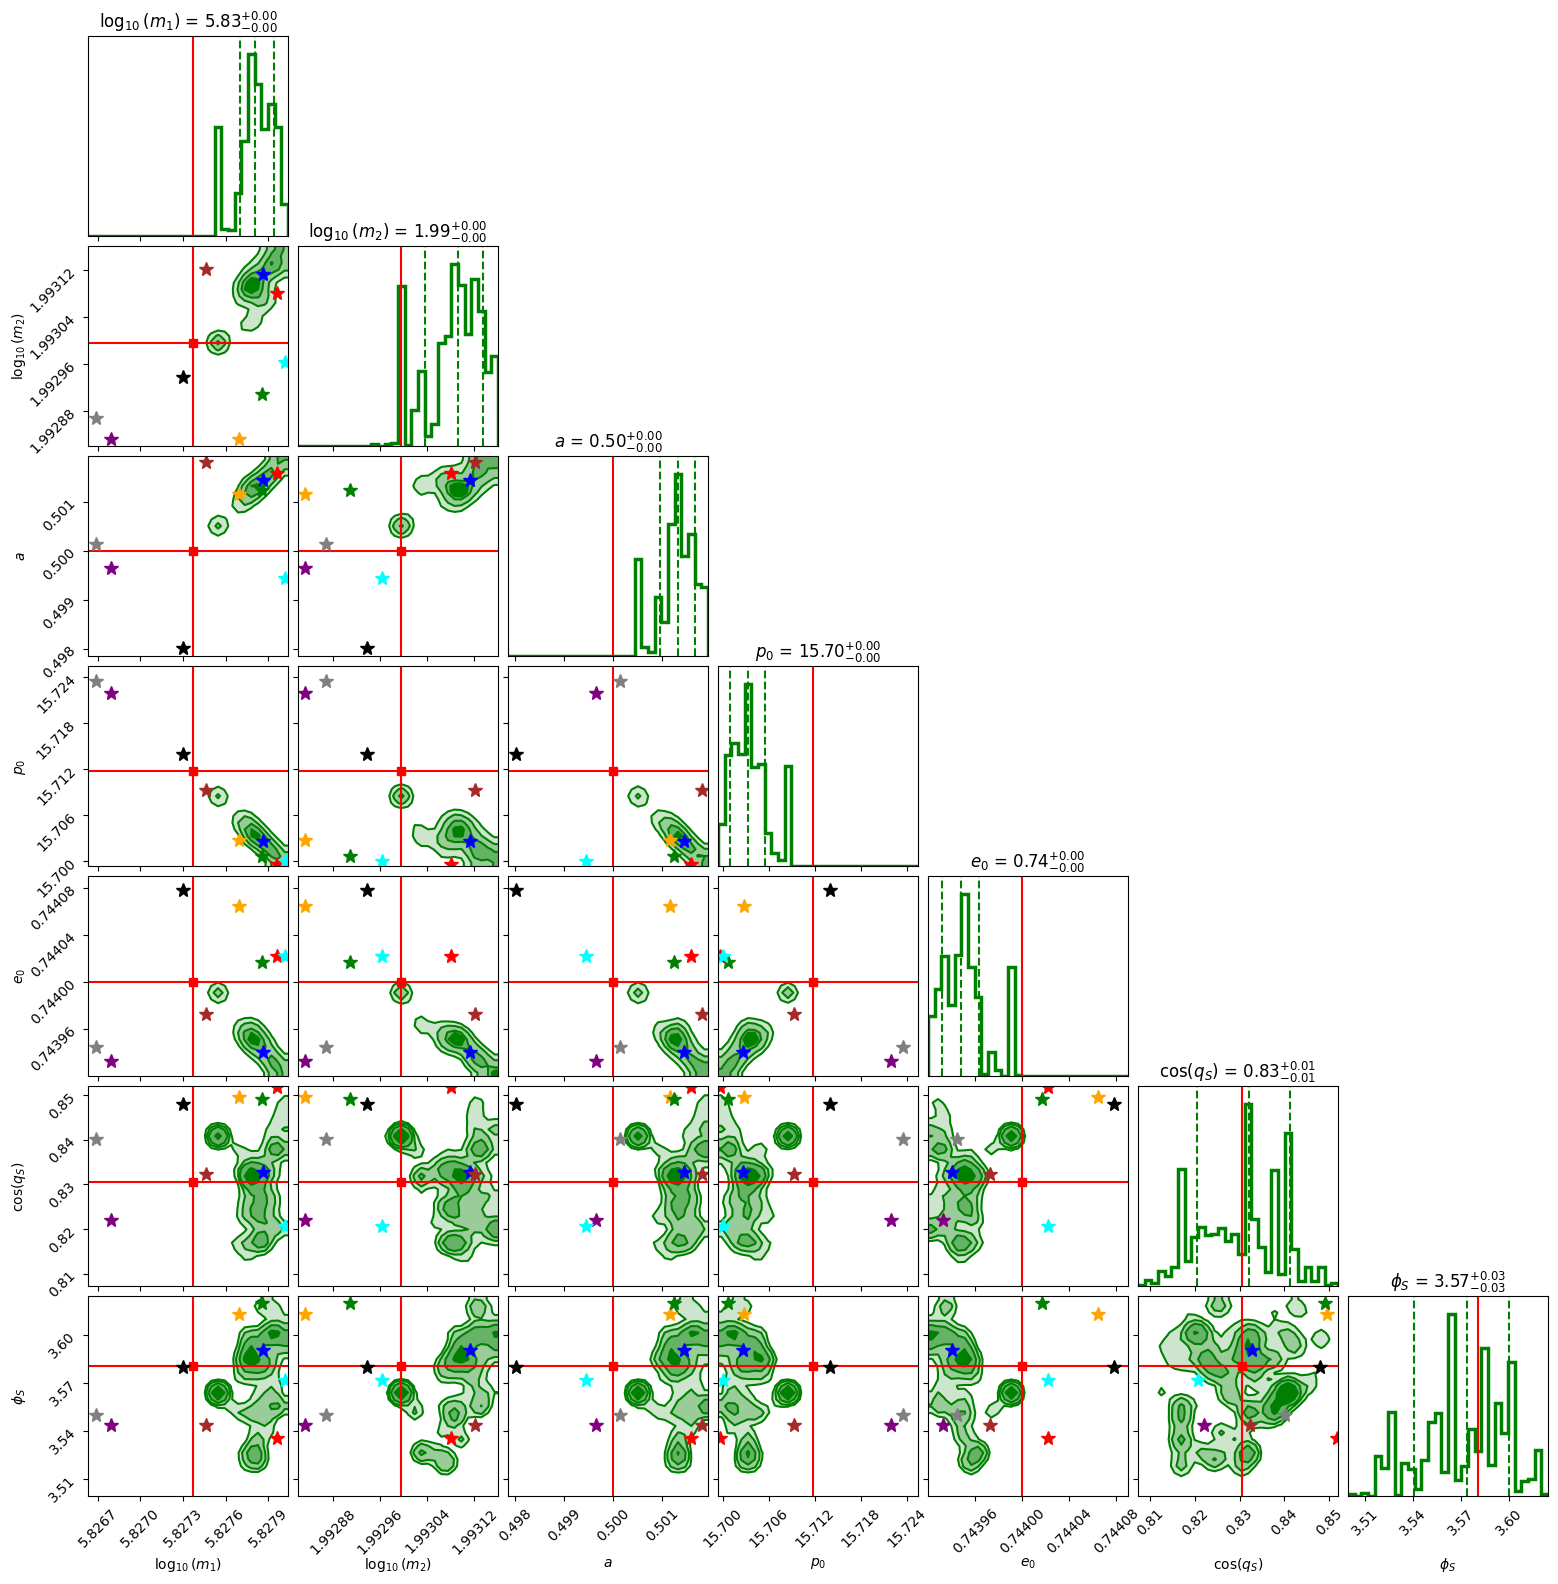

In [16]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1), 
                       color='green', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1), 
                       color='red', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt5.reshape(1, -1), 
                       color='brown', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt6.reshape(1, -1), 
                       color='purple', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt7.reshape(1, -1), 
                       color='black', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt8.reshape(1, -1), 
                       color='gray', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt9.reshape(1, -1), 
                       color='cyan', marker='*', ms=10, 
                       reverse=False)



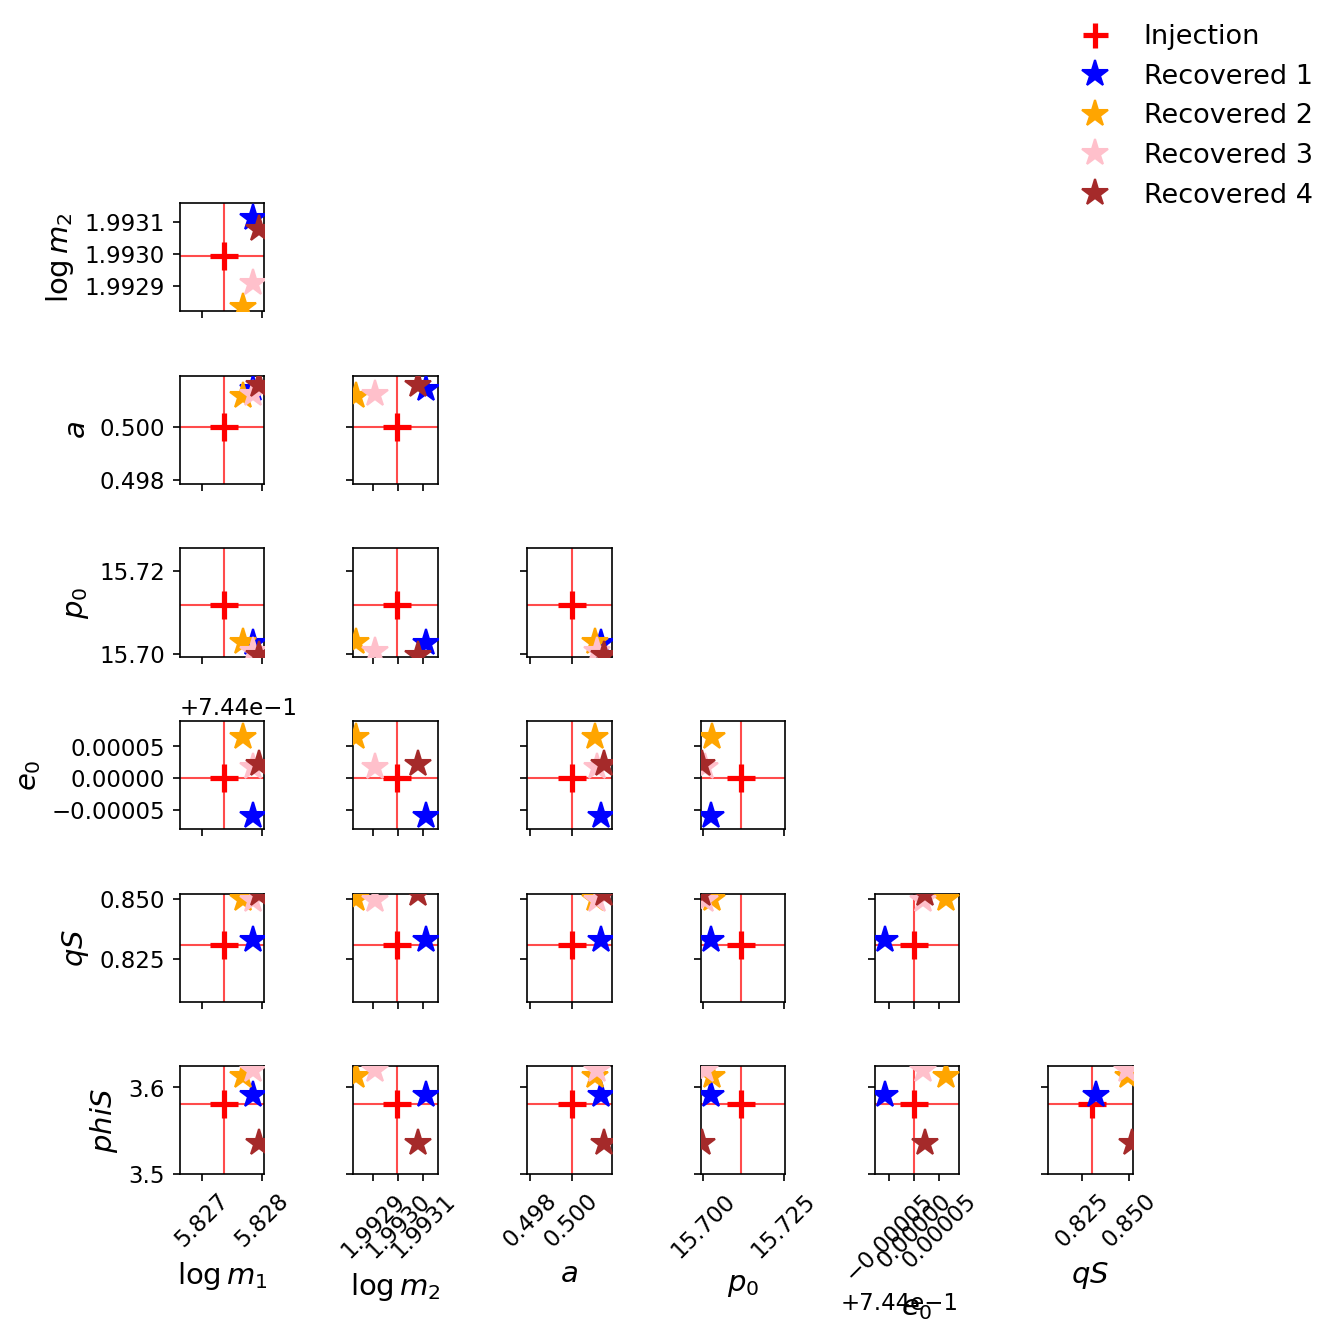

In [17]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
maxld_pt3  = np.asarray(maxld_pt3).ravel()
maxld_pt4  = np.asarray(maxld_pt4).ravel()
maxld_pt5  = np.asarray(maxld_pt5).ravel()
maxld_pt6  = np.asarray(maxld_pt6).ravel()
maxld_pt7  = np.asarray(maxld_pt7).ravel()
maxld_pt8  = np.asarray(maxld_pt8).ravel()
maxld_pt9  = np.asarray(maxld_pt9).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        # # recovered MAP point
        ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='pink',
                ms=13, zorder=4)

        ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='brown',
                ms=13, zorder=4)
                
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
    Line2D([0], [0], color='brown', marker='*', ls='', ms=13,          label='Recovered 4'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [ ]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82786211,  1.99311317,  0.50143058, 15.70258108,  0.7439405 ,
         0.8326975 ,  3.59057239]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [ ]:
def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), non-batched —
    calls loglike_obj(theta) once per row instead of loglike_obj.log_density_batch(theta_batch).
    """
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cosqS_i)
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            out[i] = float(loglike_obj(theta))
        except Exception:
            pass
    return out

In [21]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


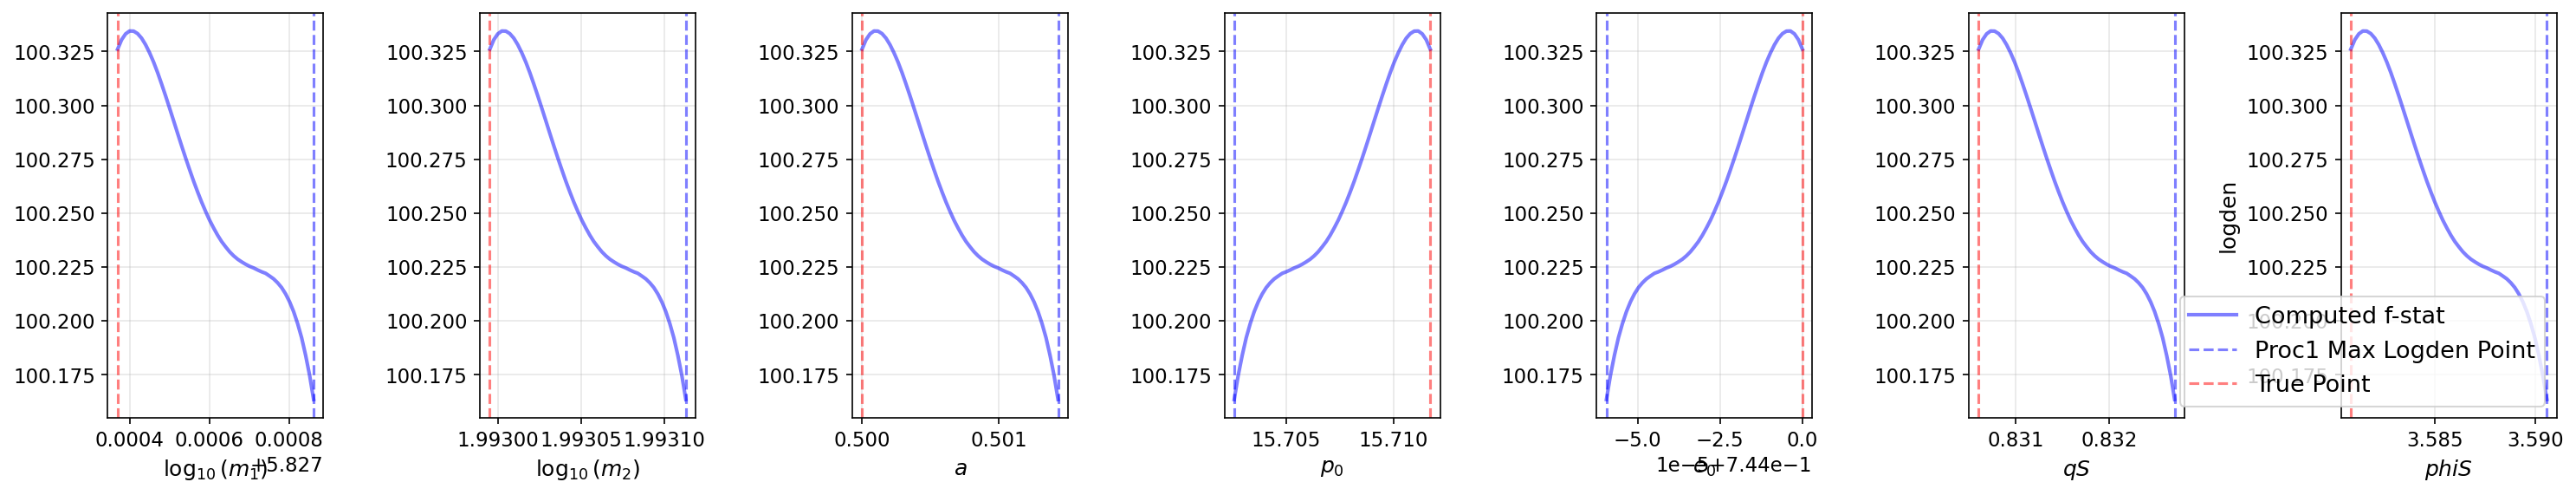

In [23]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [28]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [29]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [38]:
n_vals = np.arange(-1, 6)

In [39]:
n_vals

array([-1,  0,  1,  2,  3,  4,  5])

In [44]:
import loglike_timemax_noise

loglike_obj_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density_tm(params):

    params = np.asarray(params)
    B = params.shape[0]
    logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = (params[:, j] for j in range(7))
    qS_i = np.arccos(cosqS_i)
    theta_batch = np.stack([
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        np.full(B, xI0), np.full(B, dist), qS_i, phiS_i,
        np.full(B, qK), np.full(B, phiK),
        np.full(B, Phi_phi0), np.full(B, Phi_theta0), np.full(B, Phi_r0),
    ], axis=1)
    try:
        return loglike_obj_tm.log_density_batch(theta_batch)
    except Exception:
        return np.full(B, -np.inf)

LogLike initialized.


In [ ]:
logden_pure = log_density(line_points_logm1.T)


In [ ]:
logden_tm = log_density_tm(line_points_logm1.T)


In [42]:
logden_tm

array([-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -i

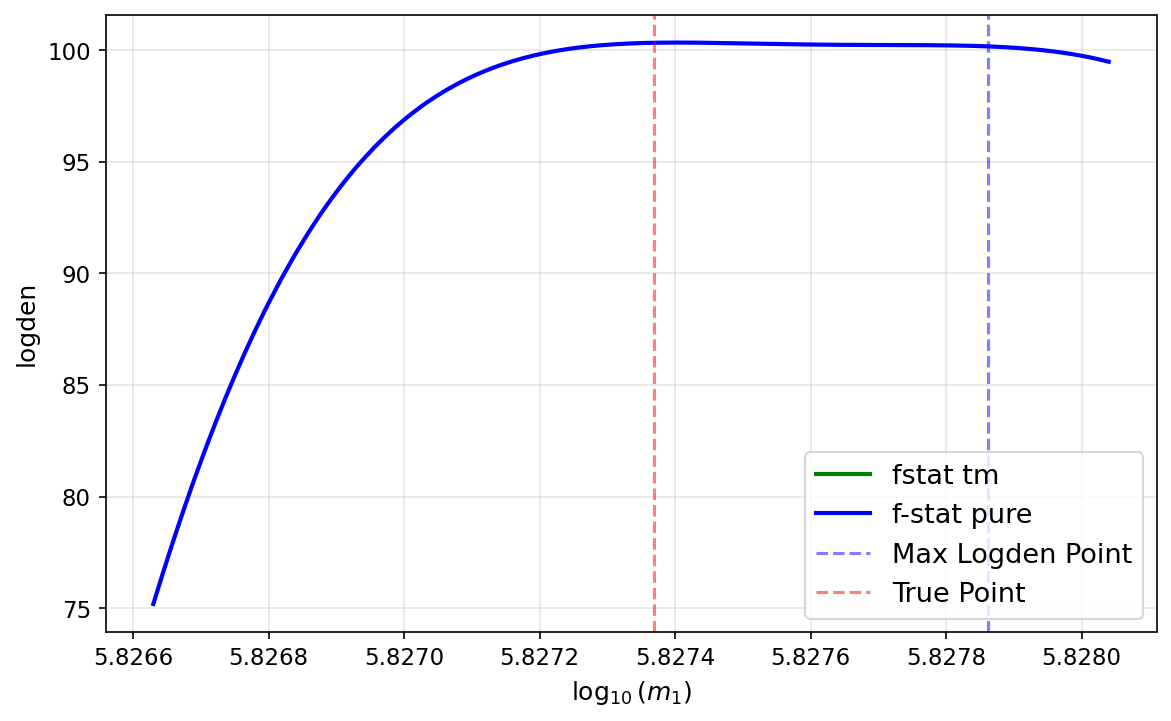

In [48]:


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='green', linewidth=2, label='fstat tm')
ax.plot(line_points_logm1[0], logden_pure, '-', color='blue', linewidth=2, label='f-stat pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
# ax.axvline(5.827366988181155, color='green', linestyle='--', alpha=0.5, label='MAP Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

# alternate mode basis

In [24]:
n_vals = np.arange(-20, 20)
loglike_obj_alt = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

def log_density_alt(params):

    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cosqS_i)
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            out[i] = float(loglike_obj_alt(theta))
        except Exception as e:
            print(e)
    return out

LogLike initialized.


In [25]:
log_density(maxld_pt1.reshape(1,-1))

array([100.16343614])

In [26]:
log_density_alt(maxld_pt1.reshape(1,-1))

array([98.73084025])

In [27]:
log_density_alt(maxld_pt1.reshape(1,-1)), log_density_alt(maxld_pt2.reshape(1,-1)), log_density_alt(maxld_pt3.reshape(1,-1)), log_density_alt(maxld_pt4.reshape(1,-1)), log_density_alt(maxld_pt5.reshape(1,-1)), \
log_density_alt(maxld_pt6.reshape(1,-1)), log_density_alt(maxld_pt7.reshape(1,-1)), log_density_alt(maxld_pt8.reshape(1,-1)), log_density_alt(maxld_pt9.reshape(1,-1))

(array([98.73084025]),
 array([18.21274268]),
 array([13.3969948]),
 array([9.58257279]),
 array([5.21017637]),
 array([4.1145008]),
 array([3.82699864]),
 array([2.86410688]),
 array([2.16310839]))

In [45]:
# Noiseless reference (ceiling)
loglike_clean = LogLike(params=params_star, waveform_response=waveform_response,
                         gwf=gwf, add_noise=False, verbose=True,
                         ell=ell, n_vals=n_vals, M_mode=None)
ceiling = loglike_clean(params_star)

# Noisy, same seed as your search's injection
loglike_noisy = LogLike(params=params_star, waveform_response=waveform_response,
                         gwf=gwf, add_noise=True, seed=42, verbose=True,
                         ell=ell, n_vals=n_vals, M_mode=None)
truth_val = loglike_noisy(params_star)

print(f"ceiling (noiseless) = {ceiling:.4g}")
print(f"truth under noise   = {truth_val:.4g}")

Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (